# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [23]:
import pickle

# Import Data

In [2]:
df = pd.read_csv('insurance_data.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


# Separate features and target

In [5]:
X = df.drop("charges", axis=1)
y = df["charges"]

# Pre-Process Data

## Define column groups

In [6]:
numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

## Create transformers

In [7]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop="first")

## Combine transformers using ColumnTransformer

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

## Create full pipeline (preprocessing + model)

In [9]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# Train-test split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model

In [11]:
model.fit(X_train, y_train)
print("Model training completed successfully.")

Model training completed successfully.


# Make predictions

In [13]:
y_pred = model.predict(X_test)

# Calculate Evaluation Metrics

In [15]:
# R² Score
r2 = r2_score(y_test, y_pred)

# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# Root Mean Squared Error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Model Evaluation Results:")
print("---------------------------")
print(f"R² Score: {r2:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

Model Evaluation Results:
---------------------------
R² Score: 0.78
MAE: 4181.19
RMSE: 5796.28


# Visualize Predicted vs Actual

## Actual vs Predicted

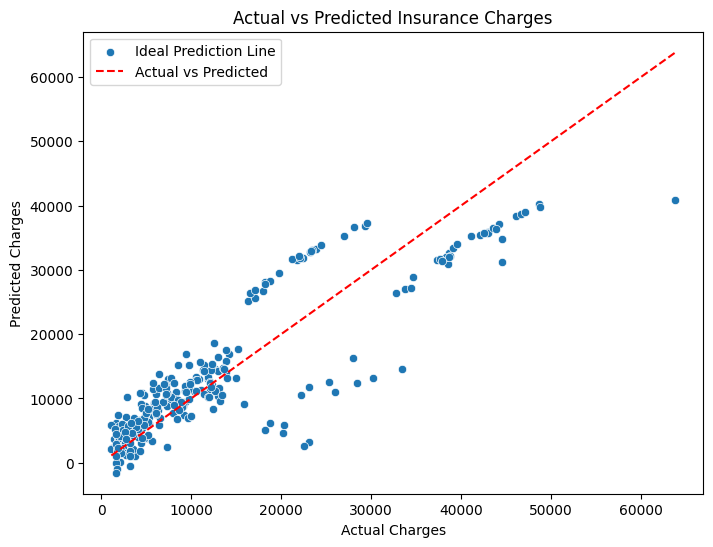

In [20]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)

# Plot ideal prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.legend(["Ideal Prediction Line", "Actual vs Predicted"])
plt.show()

## Residual Plot

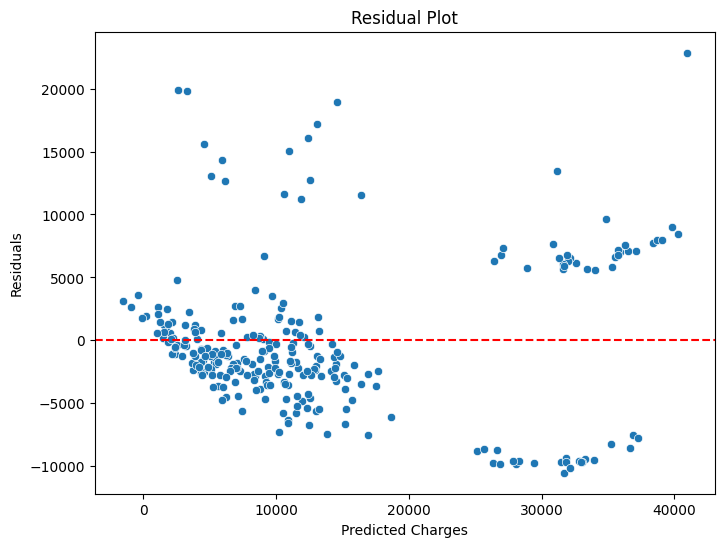

In [21]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred, y=residuals)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

## Distribution of Residuals

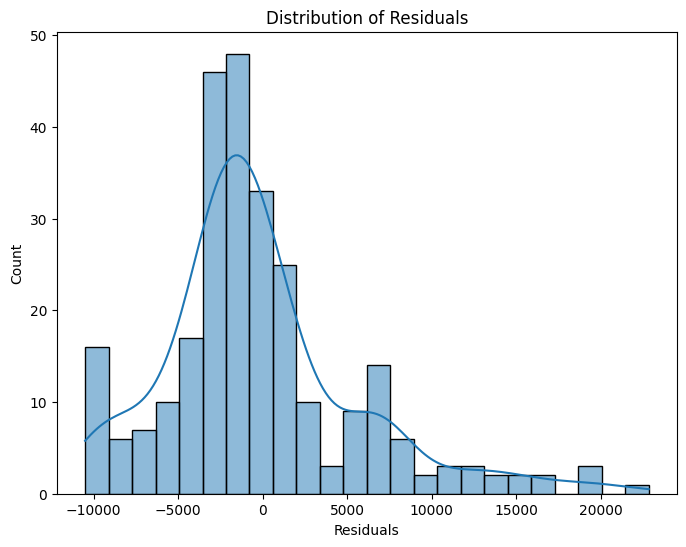

In [22]:
plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True)

plt.title("Distribution of Residuals")
plt.xlabel("Residuals")
plt.show()

# Save model to file

In [24]:
with open("insurance_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!


## Load Model

In [27]:
with open("insurance_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model loaded successfully!")

Model loaded successfully!


# Predict on New Unseen Data

In [28]:
# Create new unseen data
new_data = pd.DataFrame({
    "age": [40],
    "sex": ["male"],
    "bmi": [30.5],
    "children": [2],
    "smoker": ["yes"],
    "region": ["southeast"]
})

# Make prediction
prediction = loaded_model.predict(new_data)

print("Predicted Insurance Charges:", prediction[0])

Predicted Insurance Charges: 32454.362451963007
